# 01 Naive Models

This notebook evaluates the two required naive baselines:
- `naive_previous_week`
- `naive_previous_year`

The official naive benchmark is chosen on **validation** and then reused for relative metrics such as `rMAE`.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import time

import pandas as pd
from IPython.display import Image, display

NOTEBOOK_CWD = Path.cwd()
REPO_ROOT = next(
    path for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents] if (path / "scripts/Data/02_Forecasting/01_DA_prices").exists()
)
os.chdir(REPO_ROOT)
PACKAGE_ROOT = REPO_ROOT / "scripts/Data/02_Forecasting/01_DA_prices"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.append(str(PACKAGE_ROOT))

from hourly_da.core.config import HourlyDAPipelineConfig, MonitoringConfig
from hourly_da.core.reporting import find_latest_run, load_csv, load_json
from hourly_da.notebook_support import (
    apply_standard_matplotlib_style,
    build_compared_models_overview,
    build_dm_summary_table,
    build_model_style_map,
    build_week_metrics_for_predictions,
    build_reporting_metric_grid,
    build_reporting_summary_table,
    build_runtime_summary_table,
    estimate_run_duration_seconds,
    format_duration,
    load_selected_case_weeks,
    load_standard_report_bundle,
    render_plot_gallery,
    render_reporting_metric_dashboard,
    run_suite_with_feedback,
    style_dm_summary_table,
    style_model_overview_table,
    style_reporting_metric_grid,
    style_reporting_summary_table,
    style_runtime_summary_table,
    summarize_timing_compact,
    write_actual_vs_predicted_scatter_plot,
    write_horizon_error_plot,
    write_mae_by_hour_of_day_plot,
    write_residual_distribution_plot,
    write_standard_week_selection_plots,
    write_week_plots_for_models,
)

config = HourlyDAPipelineConfig(
    input_csv=REPO_ROOT / "data/01_cleaned/Day_ahead_prices/DA_prices/hourly/da_prices_all_regions_hourly.csv",
    raw_root=REPO_ROOT / "data/00_Raw/DA_Prices",
    cleaned_feature_root=REPO_ROOT / "data/01_cleaned",
    output_root=REPO_ROOT / "data/02_Forecasting/01_DA_prices/hourly_da",
)
output_root = config.output_root
run_root = output_root / "runs"


def latest_run_matching(pattern: str) -> Path:
    matches = sorted(run_root.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No run directories found for pattern: {pattern}")
    return matches[-1]


This optional rerun cell executes the same shared rolling-origin benchmark used by the scripts. It shows a warning, an estimate based on the latest comparable run, a live progress bar, and the actual wall-clock time when the rerun finishes.


In [2]:
ALLOW_HEAVY_RERUN = False

if ALLOW_HEAVY_RERUN:
    from dataclasses import replace

    from hourly_da.models.naive import PreviousWeekNaiveModel, PreviousYearNaiveModel
    rerun_config = replace(config)

    models = [PreviousWeekNaiveModel(), PreviousYearNaiveModel()]
    rerun_payload = run_suite_with_feedback(
        config=rerun_config,
        run_label="naive_benchmark",
        models=models,
        include_external_features=False,
        show_progress=True,
        progress_label="naive_benchmark",
    )
    print(rerun_payload["official_naive"])
else:
    print("Rerun skipped. Set ALLOW_HEAVY_RERUN = True to execute the shared benchmark pipeline from this notebook.")


Rerun skipped. Set ALLOW_HEAVY_RERUN = True to execute the shared benchmark pipeline from this notebook.


In [3]:
run_dir = find_latest_run(output_root, "naive_benchmark")
print(run_dir)

metrics_overall = load_csv(run_dir, "metrics_overall.csv")
metrics_by_reporting_level = load_csv(run_dir, "metrics_by_reporting_level.csv")
predictions_long = load_csv(run_dir, "predictions_long.csv")
timing_summary = load_csv(run_dir, "origin_timing_summary.csv")
official_naive = load_json(run_dir, "official_naive_reference.json")
diebold_mariano_by_reporting_level = load_csv(run_dir, "diebold_mariano_by_reporting_level.csv")


C:\Users\marijnvalk\PycharmProjects\Thesis\data\02_Forecasting\01_DA_prices\hourly_da\runs\20260404_135638_naive_benchmark


The cells below are the **pilot standardized reporting layer** for the thesis notebooks. The forecasting logic above stays untouched; only the post-run reporting is reorganized into a consistent overview, summary tables, week plots, diagnostics, statistical comparison, and runtime summary.


In [4]:
apply_standard_matplotlib_style()

current_suite_models = load_json(run_dir, "suite_models.json")["models"]
current_model_names = [record.get("name", record.get("model")) for record in current_suite_models]

COMPARISON_MODEL_SPECS = [
    {
        "model": "naive_previous_week",
        "display_name": "Naive previous week",
        "description": "Uses the same local hour from the previous week.",
        "role": "current",
    },
    {
        "model": "naive_previous_year",
        "display_name": "Naive previous year",
        "description": "Uses the same local hour from the previous year.",
        "role": "current",
    },
    # Later notebooks can append prior benchmark runs here, for example:
    # {"model": "sarima", "run_label": "sarima_benchmark", "display_name": "SARIMA", "role": "prior"},
]

WEEK_PLOT_MODELS = ["naive_previous_week", "naive_previous_year"]
DIAGNOSTIC_MODELS = ["naive_previous_week", "naive_previous_year"]
DM_CHALLENGER_MODELS = ["naive_previous_year"]

report_bundle = load_standard_report_bundle(
    output_root=output_root,
    current_run_dir=run_dir,
    comparison_specs=COMPARISON_MODEL_SPECS,
)
model_styles = build_model_style_map(
    report_bundle["comparison_specs"],
    official_naive_model=str(report_bundle["official_naive"]["model"]),
)
report_output_dir = output_root / "notebook_artifacts" / "01_naive_models" / run_dir.name / "standard_report"
report_output_dir.mkdir(parents=True, exist_ok=True)

print(f"Current run: {run_dir.name}")
print(f"Current models: {current_model_names}")
print(f"Official naive benchmark: {report_bundle['official_naive']['model']}")


Current run: 20260404_135638_naive_benchmark
Current models: ['naive_previous_week', 'naive_previous_year']
Official naive benchmark: naive_previous_week


## 1. Short overview of compared models


In [5]:
overview_table = build_compared_models_overview(
    report_bundle["comparison_specs"],
    official_naive_model=str(report_bundle["official_naive"]["model"]),
)
display(style_model_overview_table(overview_table))
display(pd.DataFrame([report_bundle["official_naive"]]))


Model,Internal model,Family,FS level,Role,Source scope,Source run,Official naive benchmark,Description
Naive previous week,naive_previous_week,naive,FS0,Current,Current run,naive_benchmark,Yes,Uses the same local hour from the previous week.
Naive previous year,naive_previous_year,naive,FS0,Current,Current run,naive_benchmark,,Uses the same local hour from the previous year.


,model,model_family,fs_level,dataset_split,observations_total,observations_scored,coverage_pct,mae,rmse,bias,...,reporting_level_sort_order,reporting_lead_days,reporting_lead_day_start,reporting_lead_day_end,reporting_lead_day_count,selection_policy,selection_split,selection_reporting_level,selection_metric,minimum_coverage_pct
0,naive_previous_week,naive,FS0,validation,43440,42909,98.777624,27.857794,38.182575,0.523647,...,2,"0,1,2,3,4",0,4,5,minimum_coverage_then_mae,validation,stitched_all_horizon,mae,95.0


## 2. Main validation and test summary tables

Each table reports the same thesis metrics for the three standard reporting slices:
- `D only`
- `Guidance only`
- `Stitched all-horizon`


In [6]:
validation_summary = build_reporting_summary_table(
    report_bundle["metrics_by_reporting_level"],
    split_name="validation",
    model_order=report_bundle["model_order"],
)
test_summary = build_reporting_summary_table(
    report_bundle["metrics_by_reporting_level"],
    split_name="test",
    model_order=report_bundle["model_order"],
)

if not validation_summary.empty:
    display(style_reporting_summary_table(validation_summary, caption="Validation summary"))
if not test_summary.empty:
    display(style_reporting_summary_table(test_summary, caption="Test summary"))


## 3. By-horizon error view

This figure keeps the split fixed and shows how MAE changes from `D` through `D+4`.


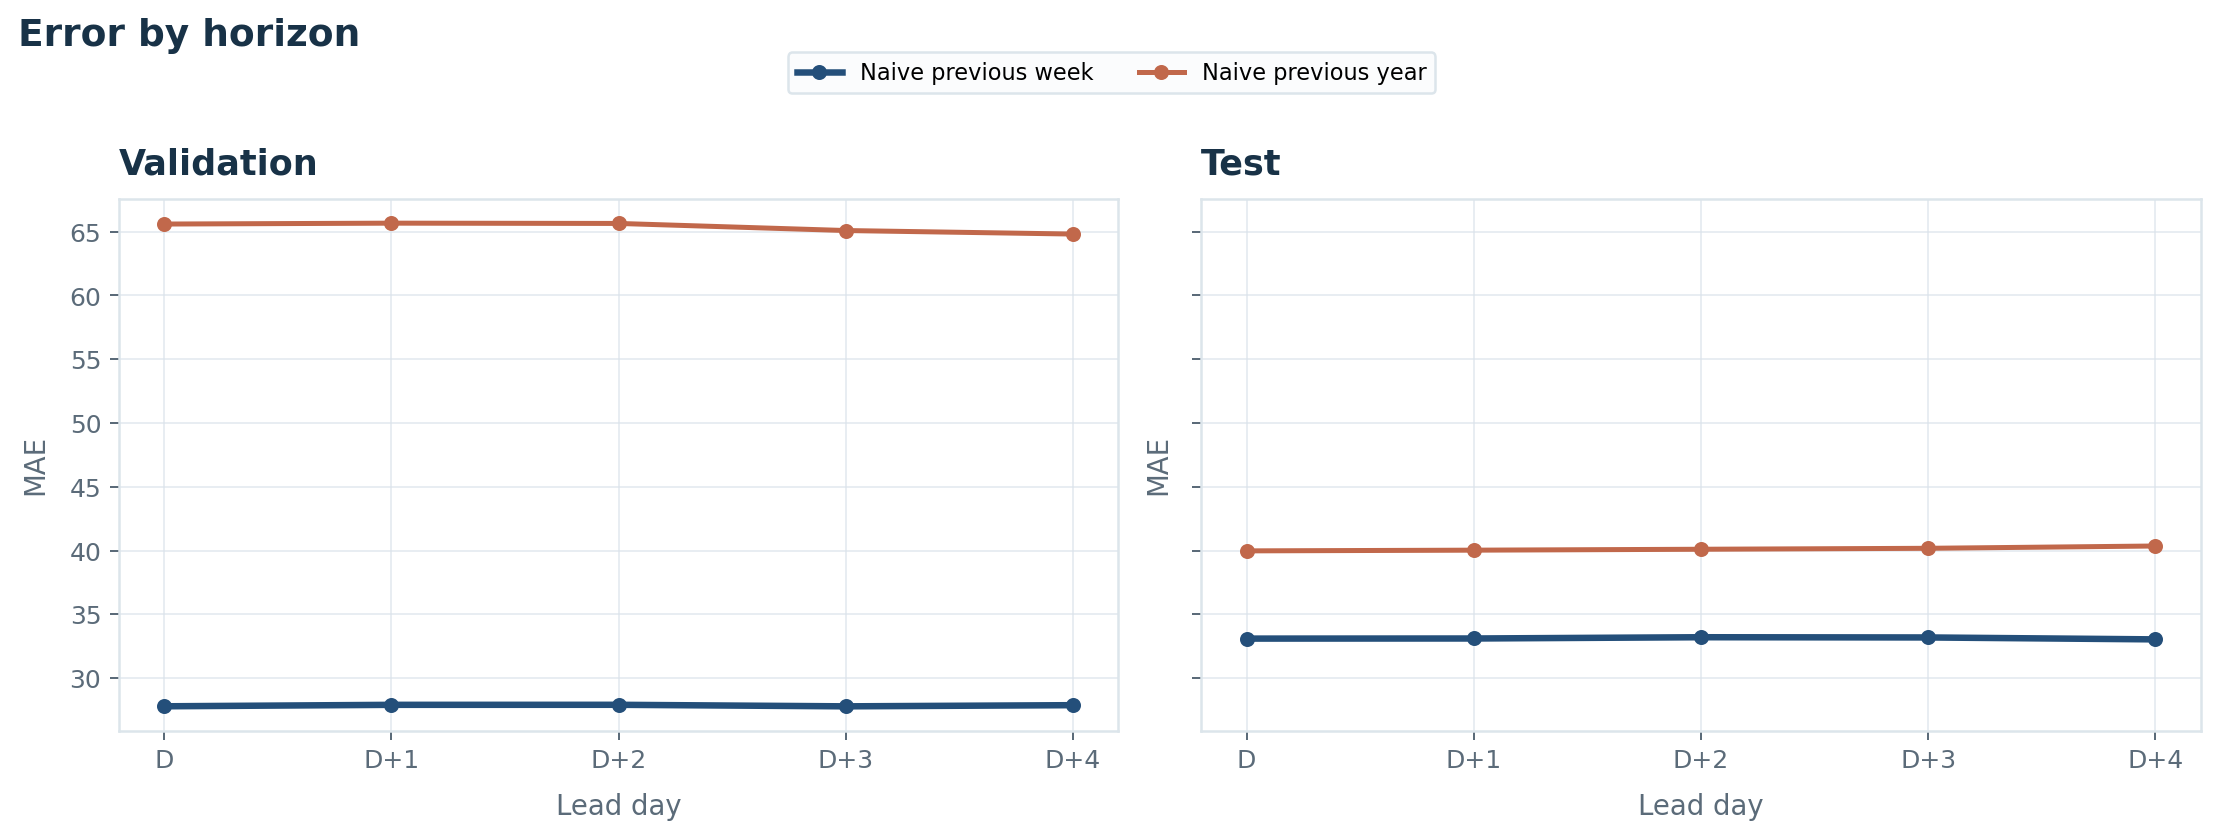

In [7]:
horizon_plot_path = write_horizon_error_plot(
    metrics_by_lead_day=report_bundle["metrics_by_lead_day"],
    output_path=report_output_dir / "horizon_error_mae.png",
    model_order=report_bundle["model_key_order"],
    model_styles=model_styles,
)
if horizon_plot_path is not None:
    display(Image(filename=str(horizon_plot_path)))


## 4. Forecast vs actual on the frozen week selections

These plots reuse the objectively selected weeks from notebook `00`. For a clean visual comparison, the overlays use the operational `D only` path so each target hour appears once.


,category,iso_week_id,week_start_local_date,week_end_local_date
0,high_price,2025-W07,2025-02-10,2025-02-16
1,high_volatility,2024-W50,2024-12-09,2024-12-15
2,low_price,2025-W38,2025-09-15,2025-09-21
3,negative_price,2025-W20,2025-05-12,2025-05-18
4,typical_summer,2025-W34,2025-08-18,2025-08-24
5,typical_winter,2025-W08,2025-02-17,2025-02-23


category,iso_week_id,Model,mae,rmse,bias,coverage_pct,max_abs_error
high_price,2025-W07,Naive previous week,28.41,37.50,-11.51,98.21%,132.26
high_price,2025-W07,Naive previous year,74.03,79.60,-73.96,99.40%,193.61
high_volatility,2024-W50,Naive previous week,72.61,136.04,-54.90,100.00%,735.06
high_volatility,2024-W50,Naive previous year,91.13,151.71,-79.41,99.40%,768.83
low_price,2025-W38,Naive previous year,34.80,51.23,+24.16,97.62%,239.77
low_price,2025-W38,Naive previous week,54.56,77.59,+34.82,96.43%,327.78
negative_price,2025-W20,Naive previous week,29.15,55.74,+3.83,99.40%,342.63
negative_price,2025-W20,Naive previous year,33.10,44.19,-16.65,99.40%,143.04
typical_summer,2025-W34,Naive previous week,13.00,24.91,+2.78,97.02%,158.70
typical_summer,2025-W34,Naive previous year,28.84,38.65,-16.58,99.40%,101.93



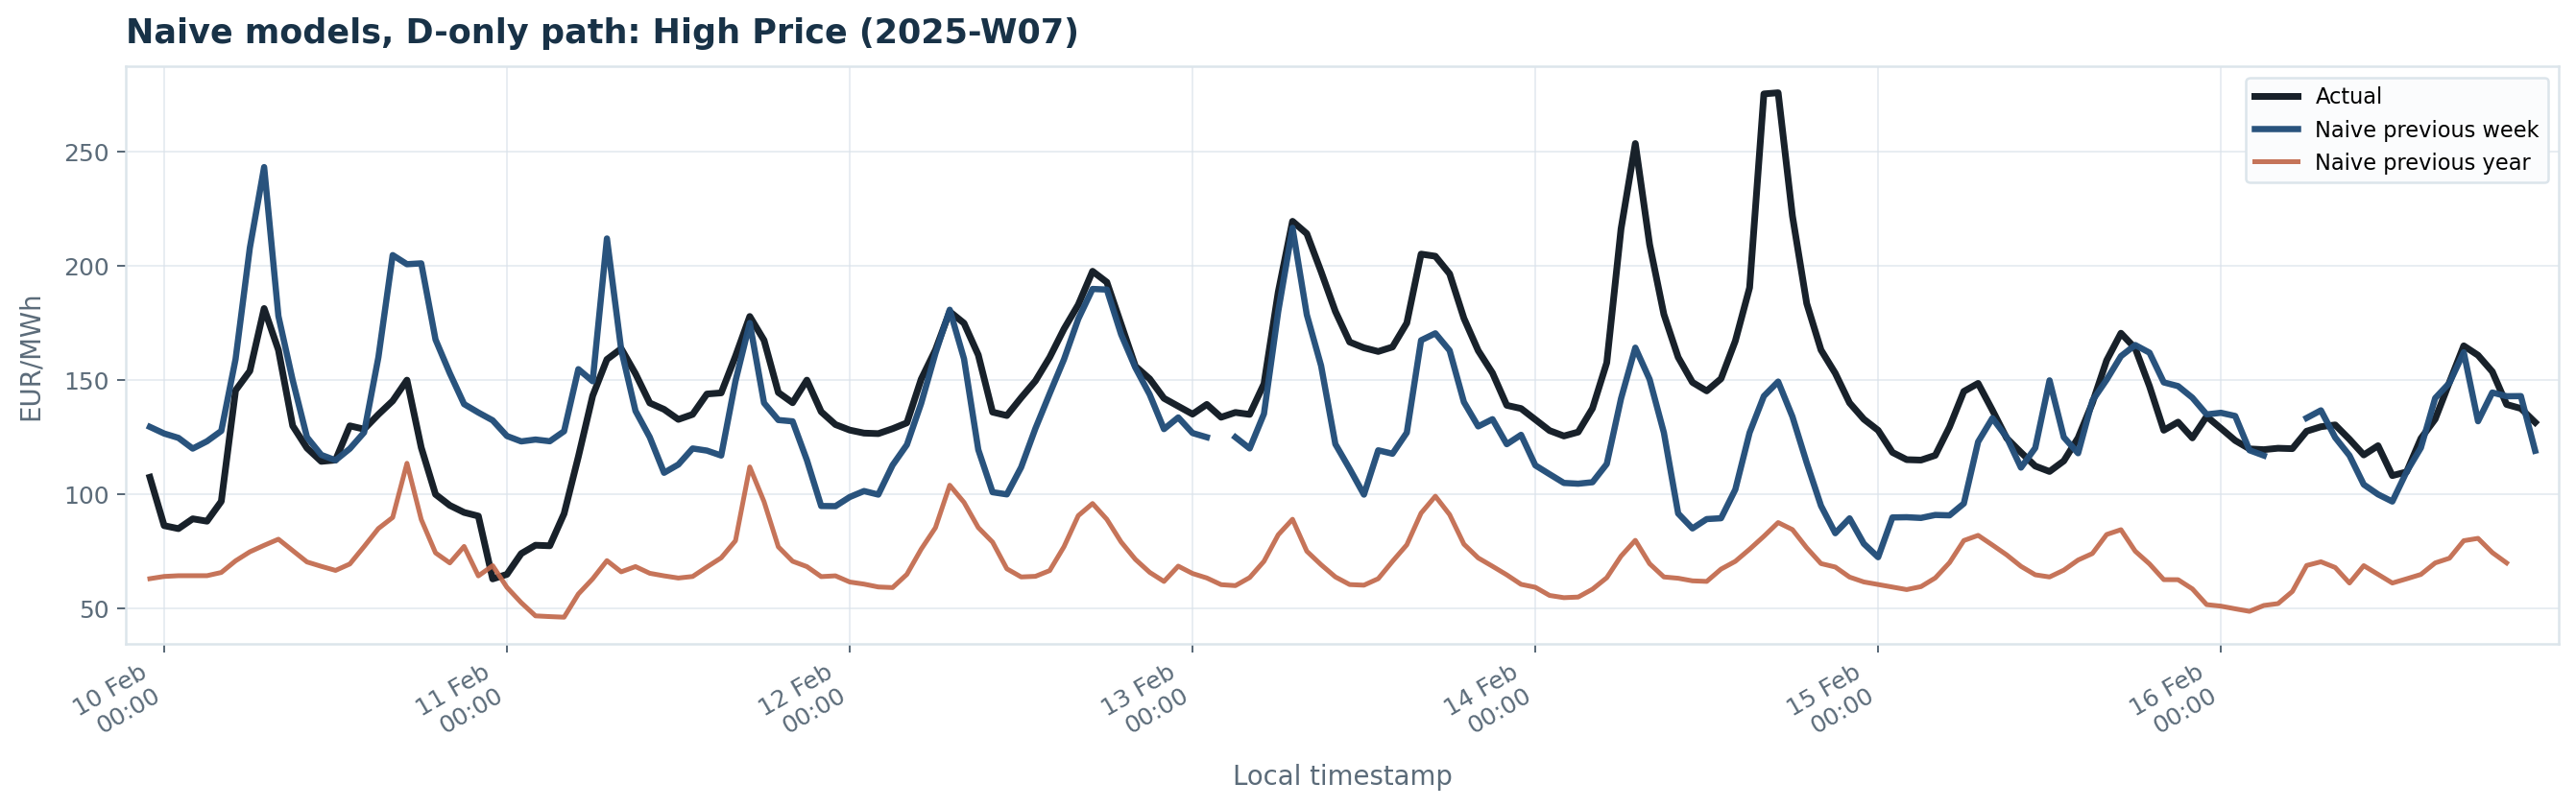
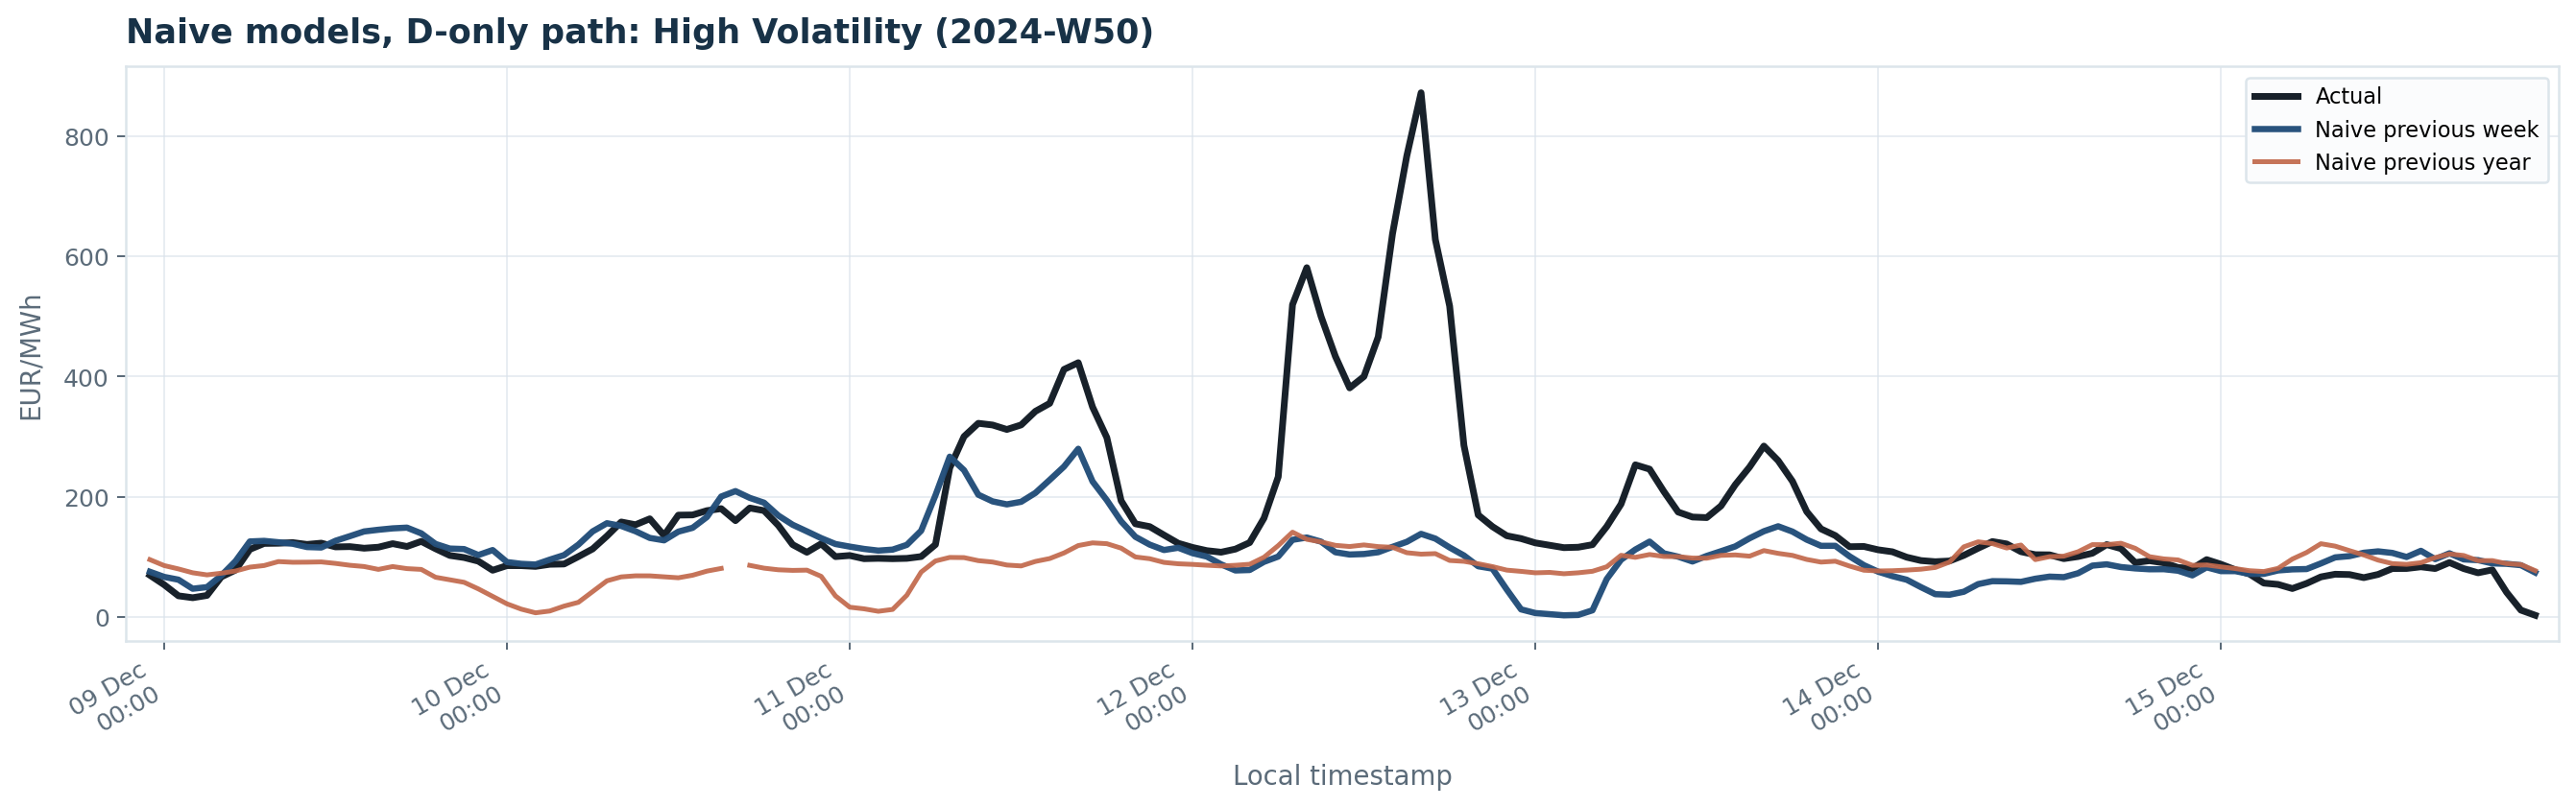
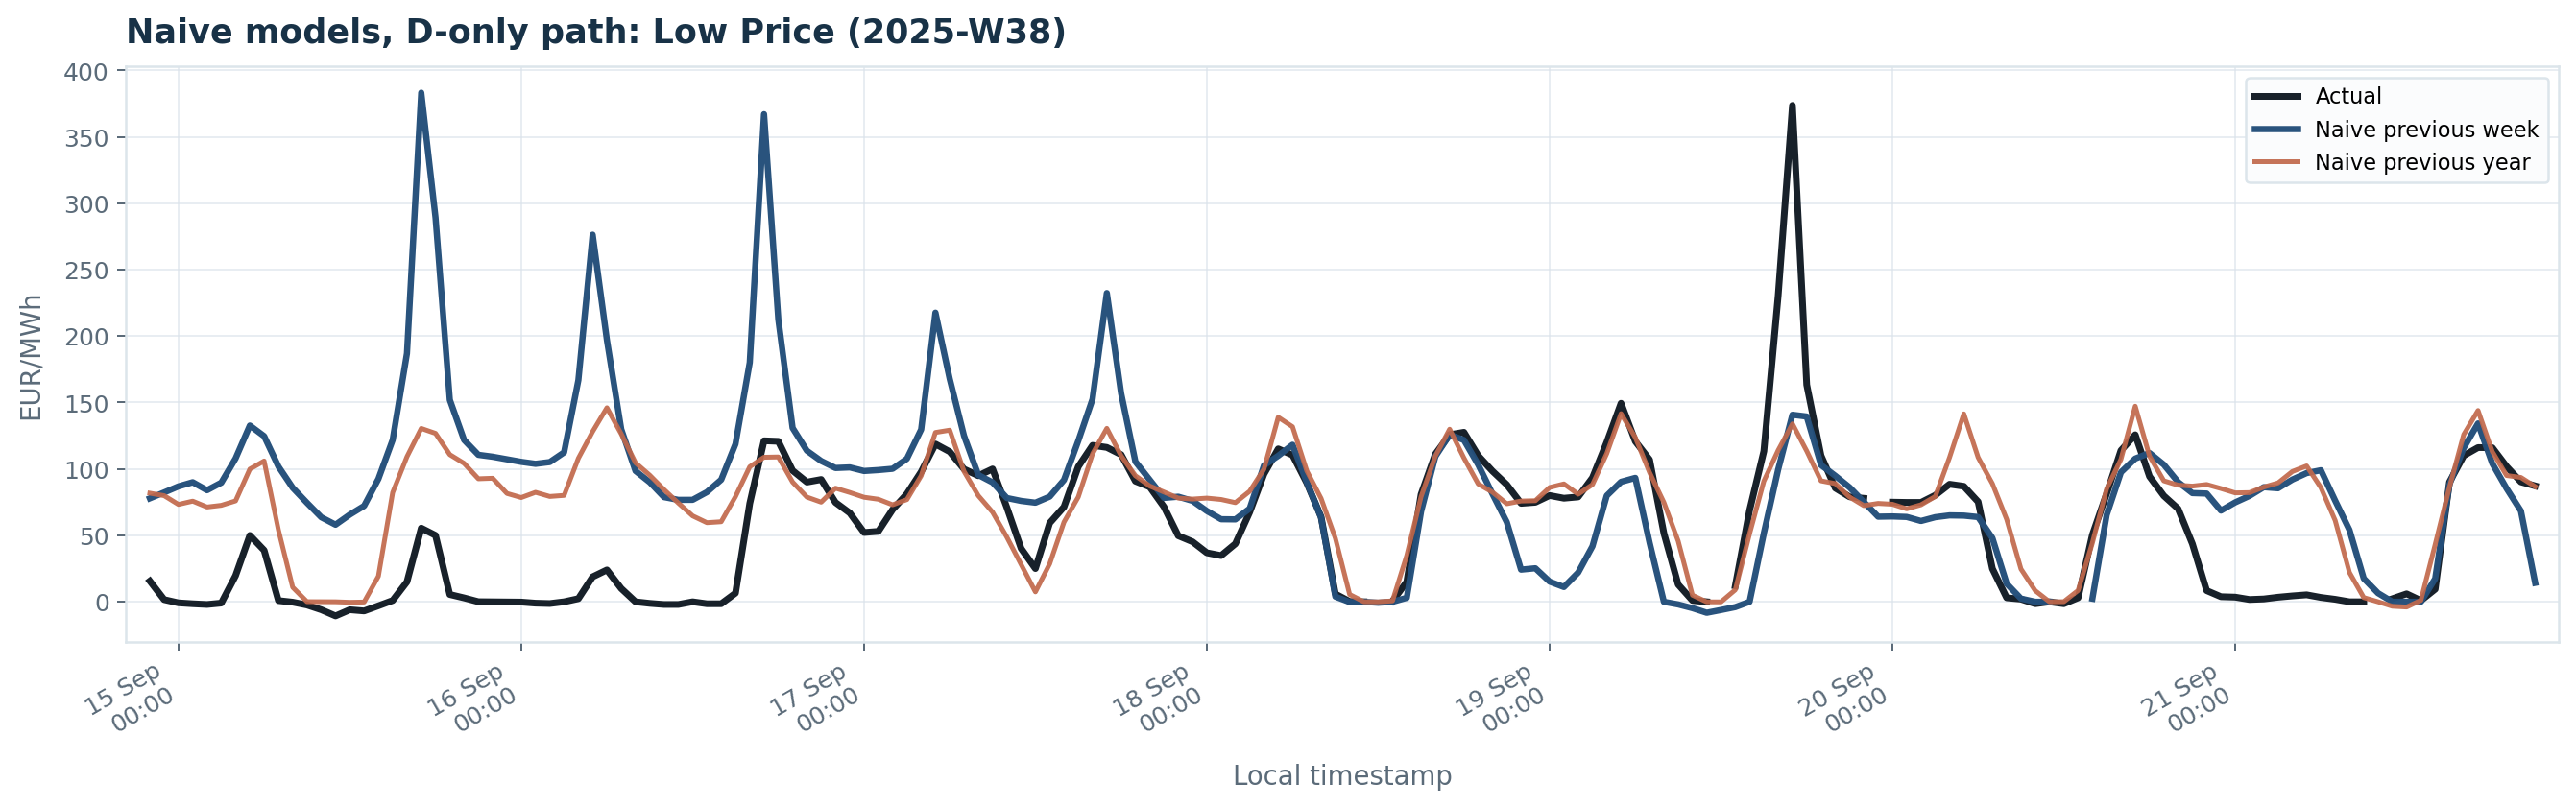
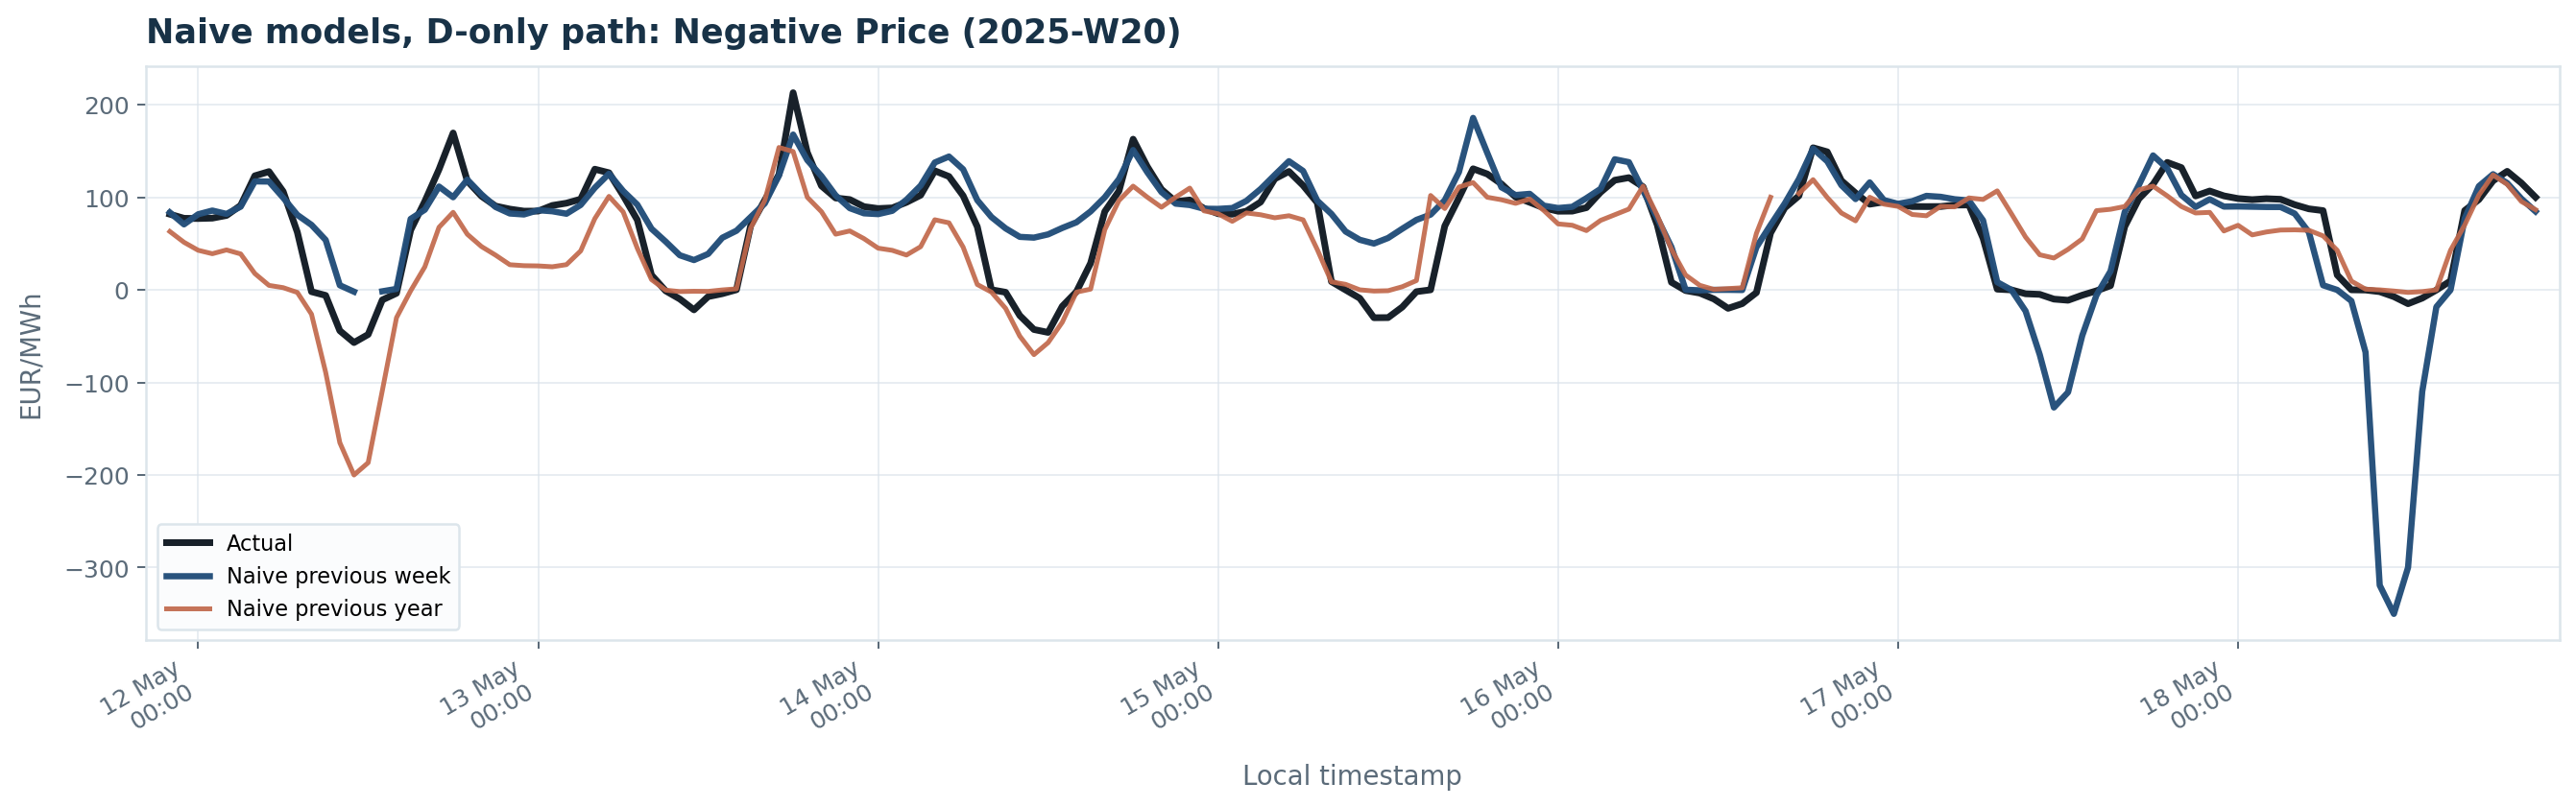
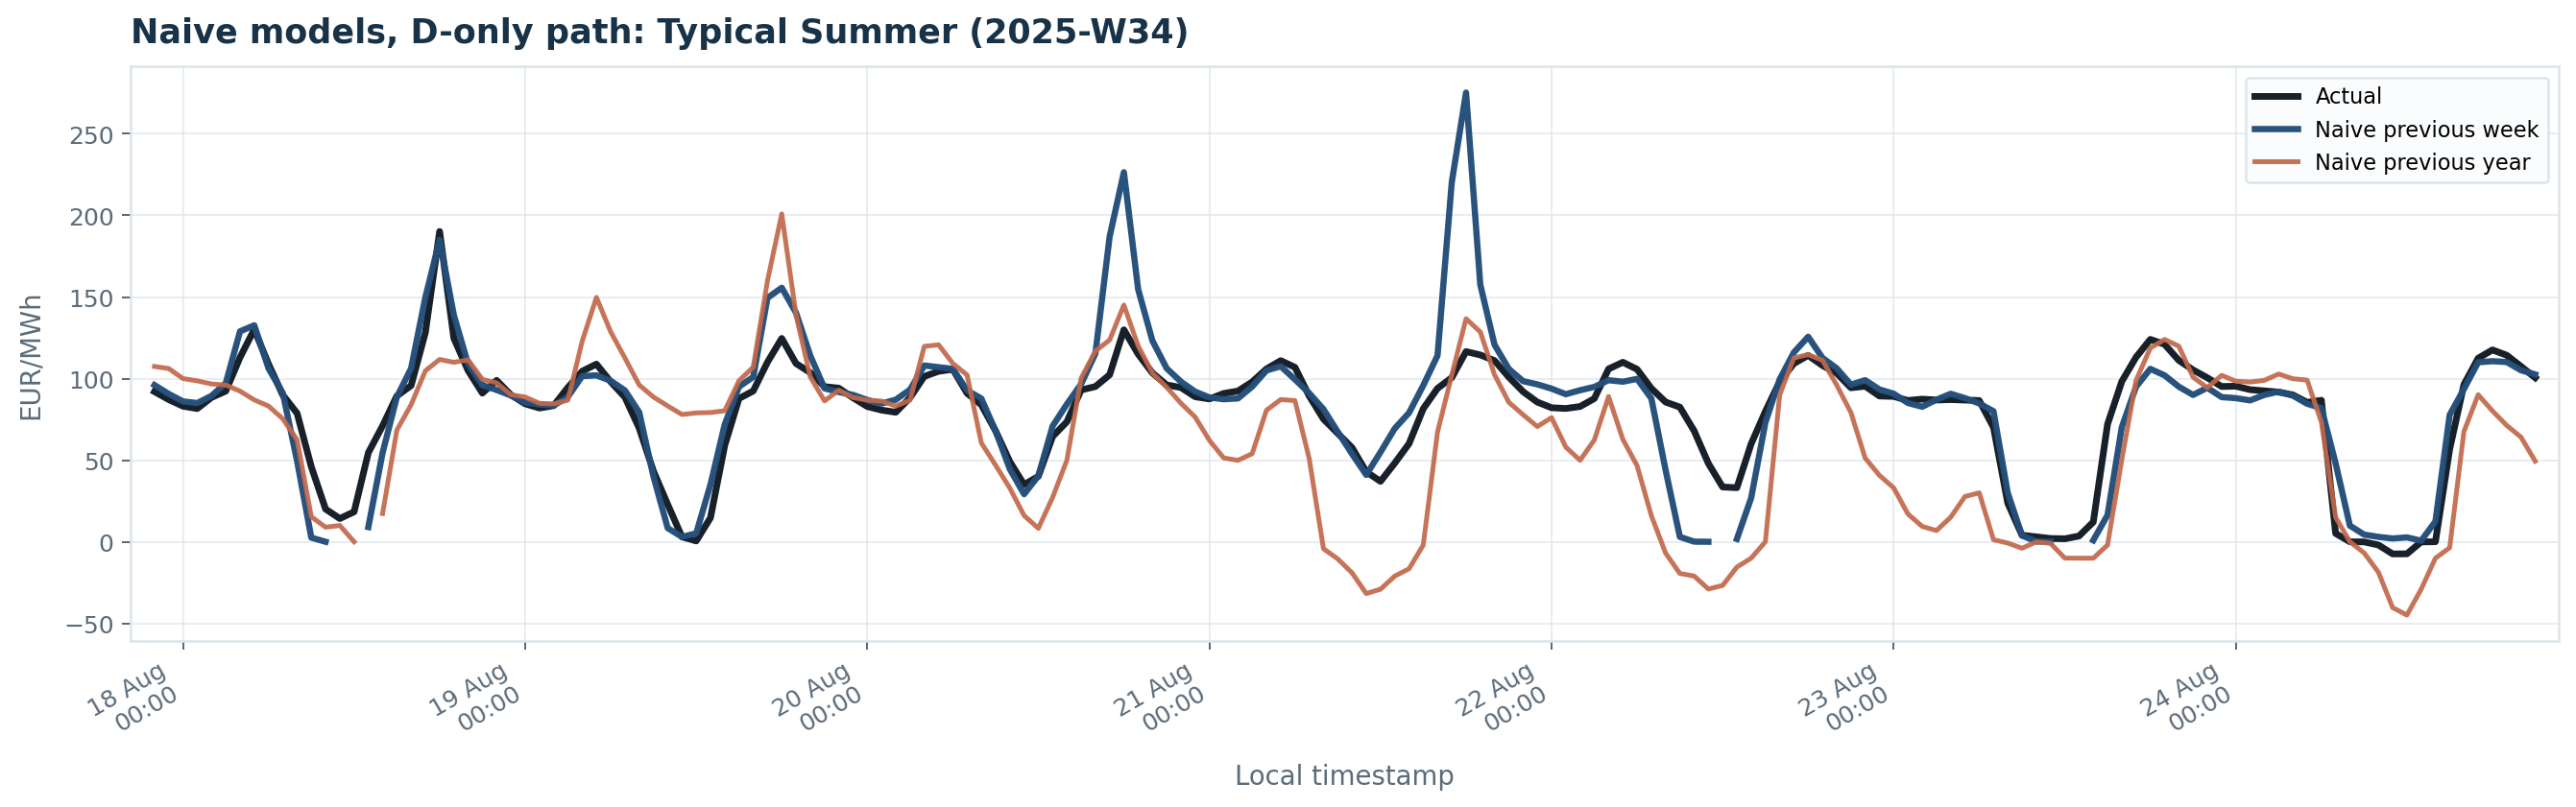
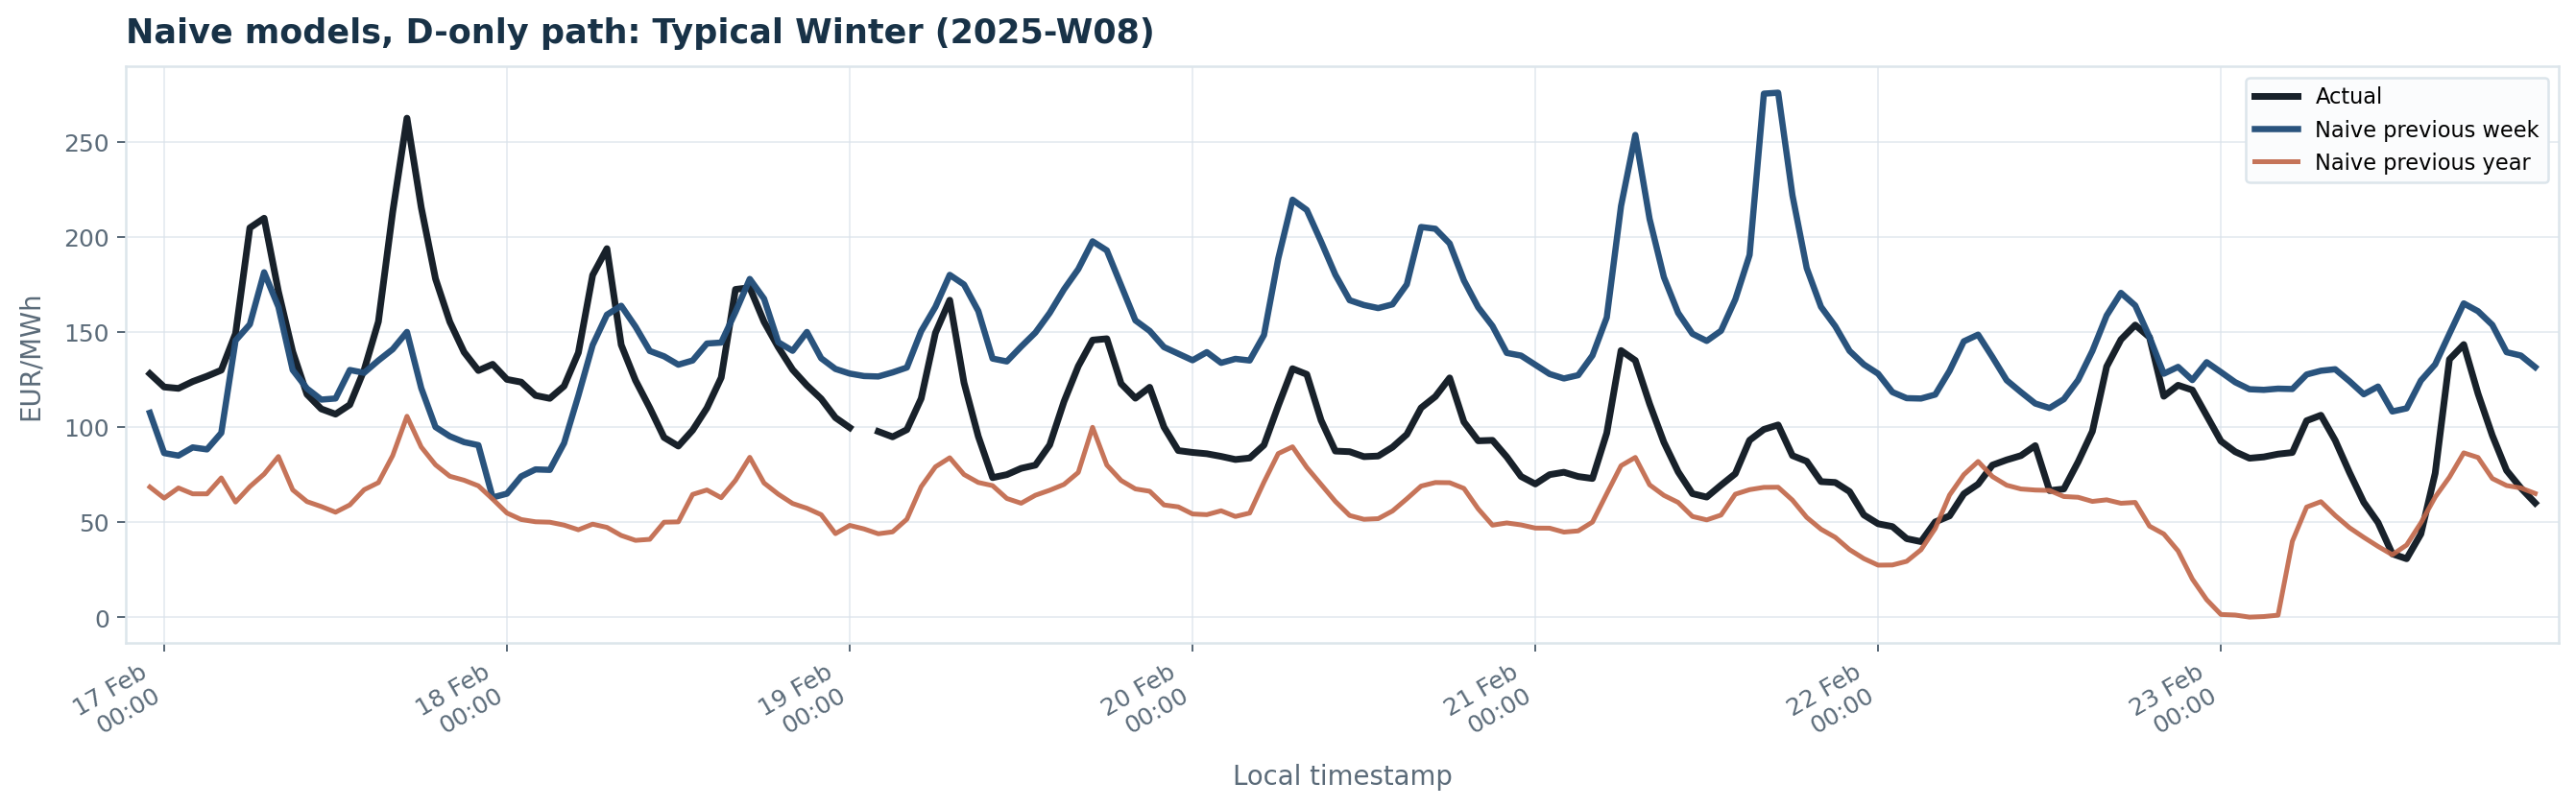

In [8]:
selection_run_dir, selected_weeks = load_selected_case_weeks(output_root)
display(selected_weeks[["category", "iso_week_id", "week_start_local_date", "week_end_local_date"]])

model_label_map = (
    report_bundle["comparison_specs"][["model", "display_name"]]
    .drop_duplicates(subset=["model"])
    .set_index("model")["display_name"]
    .to_dict()
)
week_metrics = build_week_metrics_for_predictions(report_bundle["predictions_long"], config, selected_weeks)
week_metrics_display = (
    week_metrics[week_metrics["model"].isin(WEEK_PLOT_MODELS)]
    .assign(Model=lambda frame: frame["model"].map(model_label_map).fillna(frame["model"]))
    [["category", "iso_week_id", "Model", "mae", "rmse", "bias", "coverage_pct", "max_abs_error"]]
    .sort_values(["category", "mae", "Model"])
    .reset_index(drop=True)
)
display(
    week_metrics_display.style
    .format(
        {
            "mae": "{:.2f}",
            "rmse": "{:.2f}",
            "bias": "{:+.2f}",
            "coverage_pct": "{:.2f}%",
            "max_abs_error": "{:.2f}",
        }
    )
    .hide(axis="index")
)

week_plot_paths = write_standard_week_selection_plots(
    predictions=report_bundle["predictions_long"],
    config=config,
    selected_weeks=selected_weeks,
    output_dir=report_output_dir / "week_plots",
    model_order=WEEK_PLOT_MODELS,
    model_styles=model_styles,
    split_name="test",
    reporting_level="d_only",
    title_prefix="Naive models, D-only path",
)
display(render_plot_gallery(week_plot_paths, columns=2))


## 5. Diagnostic plots

The diagnostics below focus on the **test split** and the same `D only` operational path as the week overlays, so the interpretation is based on unique forecast-target pairs rather than repeated multi-origin horizons.



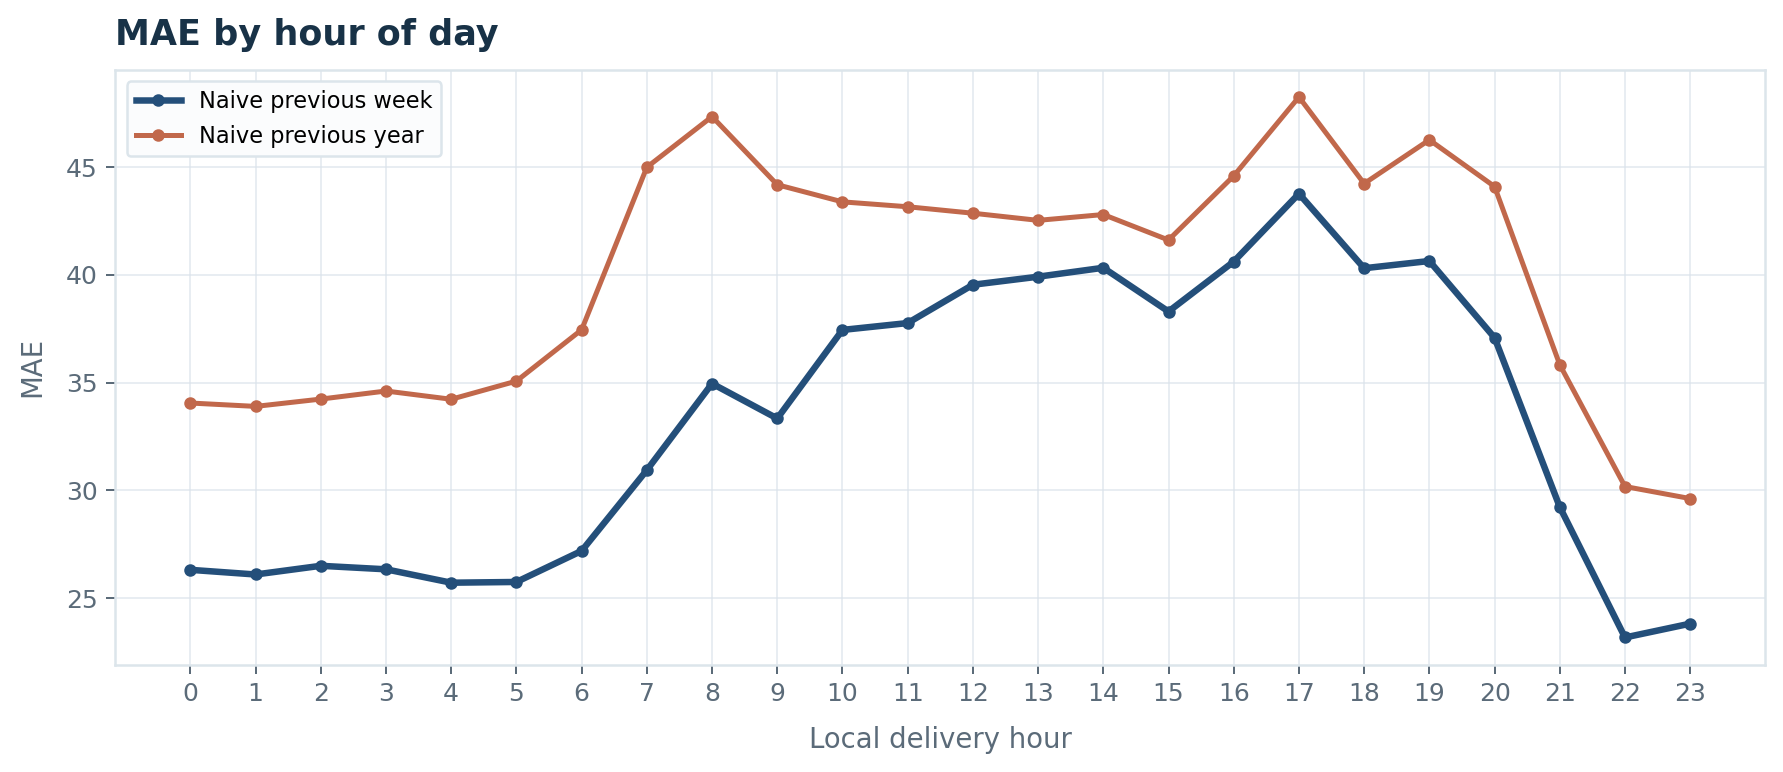
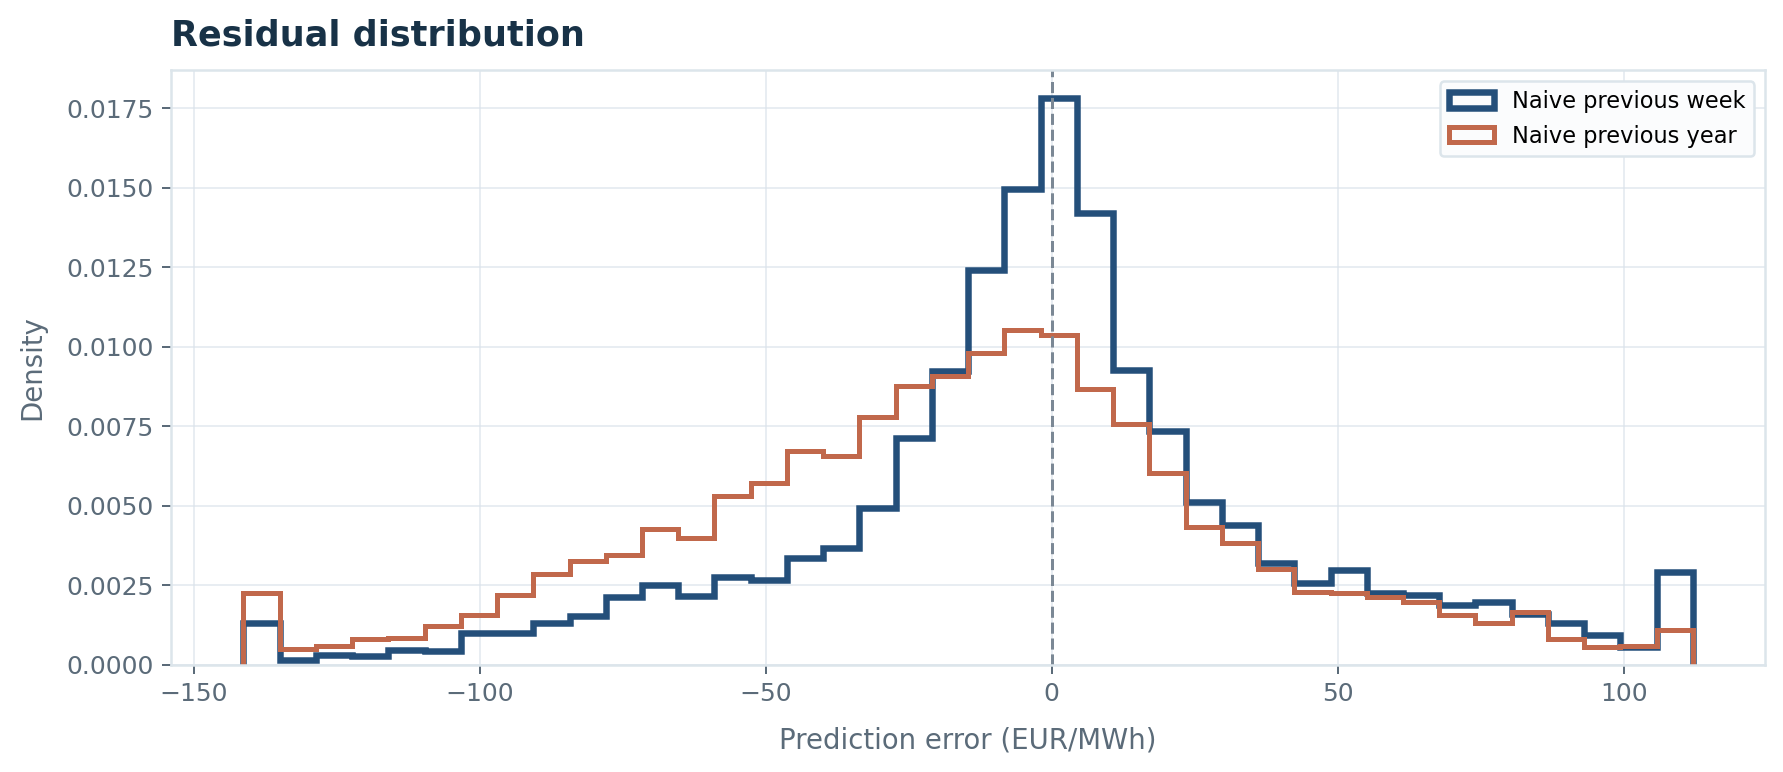
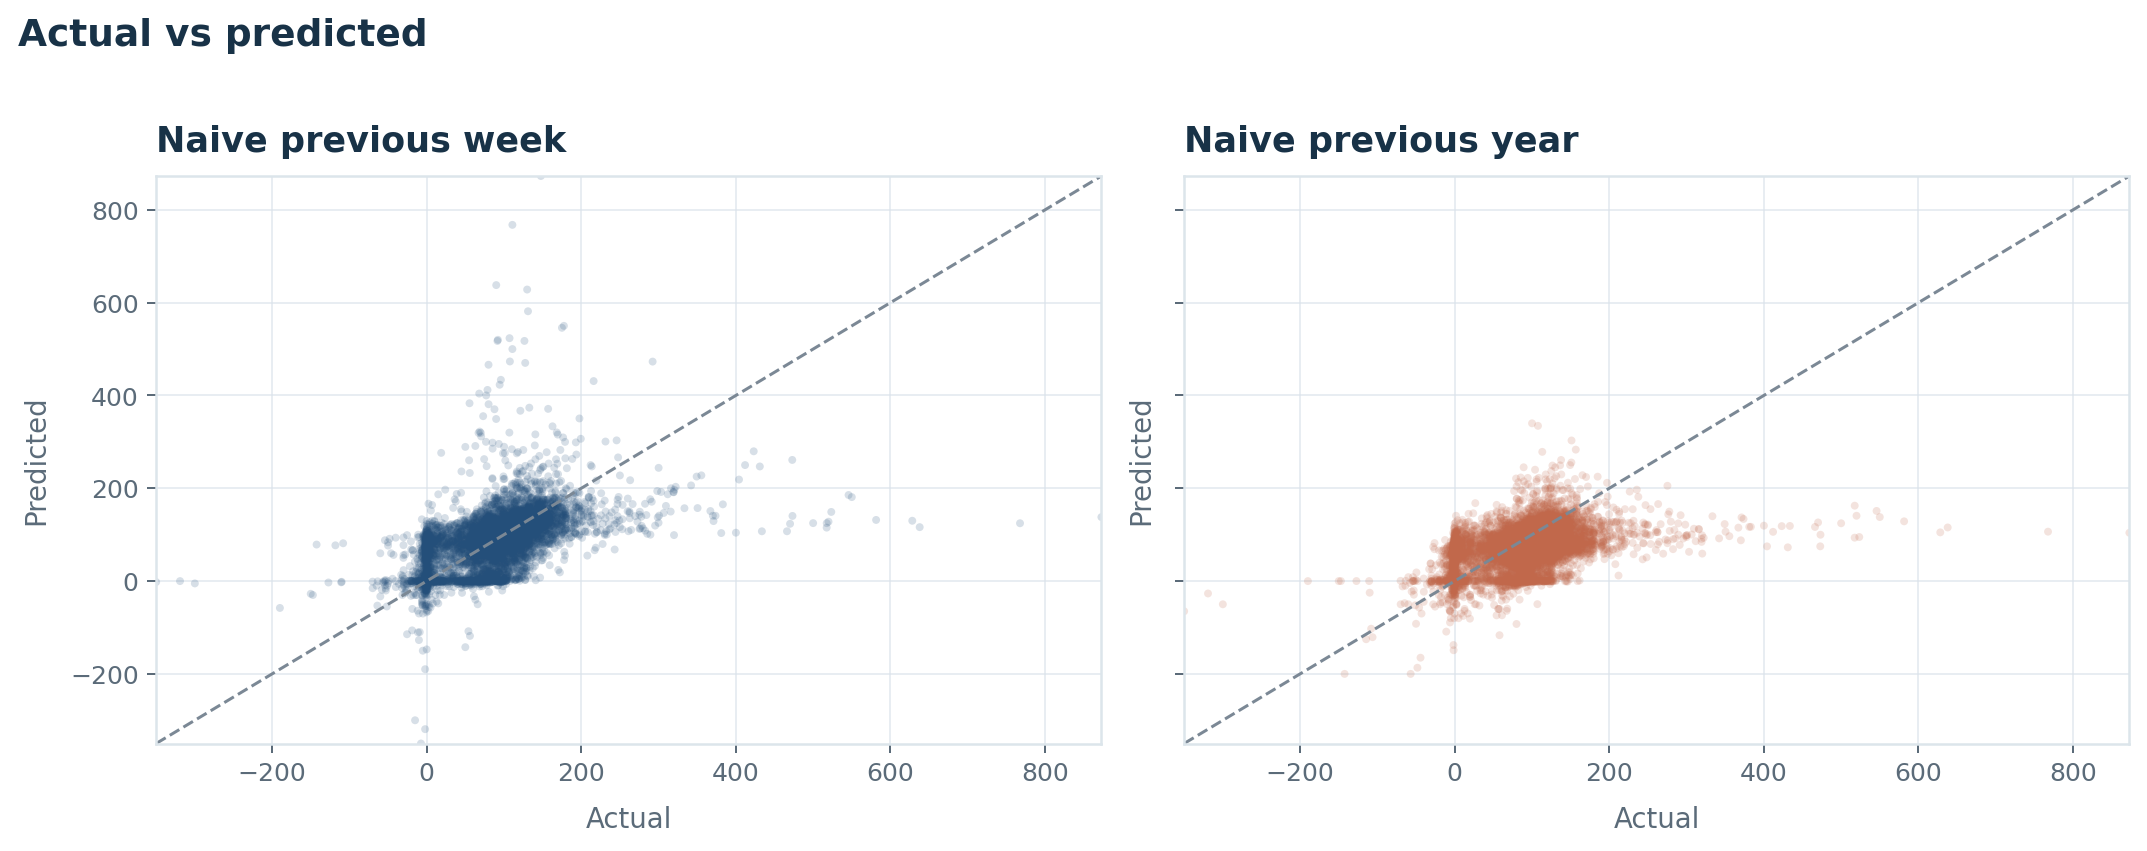

In [9]:
diagnostic_plot_paths = []

mae_by_hour_path = write_mae_by_hour_of_day_plot(
    predictions=report_bundle["predictions_long"],
    config=config,
    output_path=report_output_dir / "diagnostics" / "mae_by_hour_of_day.png",
    model_order=DIAGNOSTIC_MODELS,
    model_styles=model_styles,
)
if mae_by_hour_path is not None:
    diagnostic_plot_paths.append(mae_by_hour_path)

residual_path = write_residual_distribution_plot(
    predictions=report_bundle["predictions_long"],
    config=config,
    output_path=report_output_dir / "diagnostics" / "residual_distribution.png",
    model_order=DIAGNOSTIC_MODELS,
    model_styles=model_styles,
)
if residual_path is not None:
    diagnostic_plot_paths.append(residual_path)

scatter_path = write_actual_vs_predicted_scatter_plot(
    predictions=report_bundle["predictions_long"],
    config=config,
    output_path=report_output_dir / "diagnostics" / "actual_vs_predicted.png",
    model_order=DIAGNOSTIC_MODELS,
    model_styles=model_styles,
)
if scatter_path is not None:
    diagnostic_plot_paths.append(scatter_path)

display(render_plot_gallery(diagnostic_plot_paths, columns=2))


## 6. Statistical comparison

The Diebold-Mariano table is interpreted as follows:
- negative DM statistic favors the challenger
- positive DM statistic favors the benchmark
- the verdict column applies a `p < 0.05` threshold


In [10]:
dm_display_order = [
    row["display_name"]
    for row in report_bundle["comparison_specs"].to_dict(orient="records")
    if row["model"] in DM_CHALLENGER_MODELS
]
dm_summary = build_dm_summary_table(
    report_bundle["diebold_mariano_by_reporting_level"][
        report_bundle["diebold_mariano_by_reporting_level"]["challenger_model"].isin(DM_CHALLENGER_MODELS)
    ].copy(),
    challenger_display_order=dm_display_order,
)
display(style_dm_summary_table(dm_summary))


Split,Challenger,Benchmark,Reporting level,Observations,DM stat,p-value,Verdict
test,Naive previous year,Naive previous week,D only,"8,492",4.20,<0.001,Benchmark better
test,Naive previous year,Naive previous week,Guidance only,"33,960",8.75,<0.001,Benchmark better
test,Naive previous year,Naive previous week,Stitched all-horizon,"42,452",9.74,<0.001,Benchmark better
validation,Naive previous year,Naive previous week,D only,"8,536",11.66,<0.001,Benchmark better
validation,Naive previous year,Naive previous week,Guidance only,"34,150",23.36,<0.001,Benchmark better
validation,Naive previous year,Naive previous week,Stitched all-horizon,"42,686",26.14,<0.001,Benchmark better


## 7. Runtime and practicality summary


In [11]:
runtime_summary = build_runtime_summary_table(
    report_bundle["timing_summary"],
    model_order=report_bundle["model_order"],
)
display(style_runtime_summary_table(runtime_summary))


Model,Split,Origins,Fit mean (s),Predict mean (s),Fit max (s),Fit warnings
Naive previous week,validation,362,0.0009,0.0014,0.105,0
Naive previous week,test,361,0.0006,0.0013,0.0022,0
Naive previous year,validation,362,0.0002,0.0014,0.0006,0
Naive previous year,test,361,0.0002,0.0013,0.0006,0
